In [26]:
import sys 
from math import floor, ceil

sys.path.append('../src')
import sys
print(sys.executable)
from main import DataPipeline

pipeline = DataPipeline()
df = pipeline.pre_process_data()
df_engineered = pipeline.feature_engineering(df)
# df_engineered.columns
print(df_engineered['recovery_score_shift'].isnull().sum())

/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/bin/python
1


# 1.1 Splitting the data
Here a 70/30 split in a temporally ascending order will be taken with a 7 day washout period between these splits to ensure there is data leakage with the 7 day rolling averages.
70:30 split used in this time series dataset to capture any seasonal trends within the data

In [27]:
row_count = len(df_engineered)
row_count_washout_removal = row_count - 7
train_upper_bound = floor(row_count_washout_removal * 0.7)
test_lower_bound = train_upper_bound + 7 
df_engineered = df_engineered.sort_values('date_local').reset_index(drop=True)

train = df_engineered.iloc[7:train_upper_bound]
test = df_engineered.iloc[test_lower_bound:-1]

print(f"Train - Start Date: {train['date_local'].min()} | End Date: {train['date_local'].max()} | Number of Rows: {len(train)} | % of Total Rows: {len(train) / row_count}")
print(f"Test - Start Date: {test['date_local'].min()} | End Date: {test['date_local'].max()} | Number of Rows: {len(test)} | % of Total Rows: {len(test) / row_count}")


Train - Start Date: 2024-01-08 06:26:25.219000 | End Date: 2025-09-11 03:42:40.847000 | Number of Rows: 606 | % of Total Rows: 0.6862967157417894
Test - Start Date: 2025-09-20 08:01:07.809000 | End Date: 2026-06-08 06:05:57.868000 | Number of Rows: 262 | % of Total Rows: 0.29671574178935445


# 1.2 Split out Features and Label
Labels: Recovery Score Shift (-1 day)

In [ ]:
features = [col for col in train.columns if col not in ['recovery_score_shift', 'date_local']]
label = [col for col in train.columns if col not in features and col not in 'date_local']

X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]


print(f"Features: {features}")
print(f"Label: {label}")


recovery_score_shift    0
dtype: int64
Features: ['recovery_score', 'resting_heart_rate', 'hrv_rmssd_milli', 'skin_temp_celsius', 'sleep_efficiency_percentage', 'sleep_consistency_percentage', 'sleep_performance_percentage', 'respiratory_rate', 'sleep_cycle_count', 'disturbance_count', 'sleep_needed_baseline_milli', 'sleep_needed_need_from_recent_strain_milli', 'cycle_strain', 'cycle_avg_heart_rate', 'cycle_kilojoule', 'total_in_bed_time_hours', 'total_rem_sleep_time_hours', 'total_sleep_time_hours', 'hrv_rmssd_milli_rolling_avg_7', 'resting_heart_rate_rolling_avg_7', 'cycle_strain_rolling_avg_7', 'day_of_week', 'anomalous_day_flag', 'sleep_start_local_decimal', 'sleep_end_local_decimal']
Label: ['recovery_score_shift']


# 2.1 Baseline Linear Regression Plots

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.2f}")
print(f"The Linear Model explains {r2_score(y_test, y_pred_lr)*100:.2f}% of the variance in tomorrows Recovery Score")

recovery_score_shift
66.0                    20
60.0                    16
46.0                    15
71.0                    15
70.0                    14
                        ..
20.0                     1
2.0                      1
8.0                      1
50.0                     1
97.0                     1
Name: count, Length: 90, dtype: int64
recovery_score_shift
64.0                    14
68.0                     9
81.0                     8
60.0                     7
87.0                     7
                        ..
86.0                     1
94.0                     1
91.0                     1
96.0                     1
97.0                     1
Name: count, Length: 82, dtype: int64
MAE: 13.09
RMSE: 16.52
R2: 0.32
The Linear Model explains 31.97% of the variance in tomorrows Recovery Score


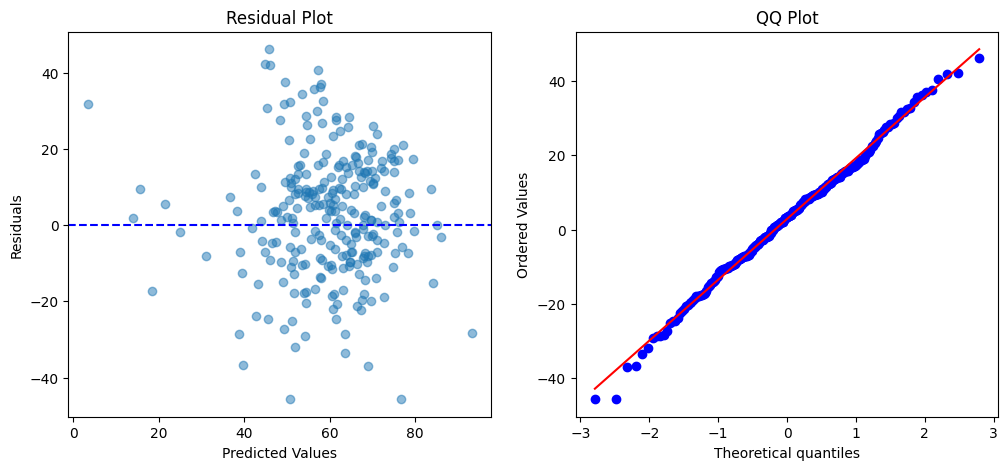

In [64]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import probplot


residuals = np.subtract(np.array(y_test), y_pred_lr).astype(float).flatten() # difference between actual and predicted

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(y_pred_lr, residuals, alpha=0.5)
ax1.axhline(y=0, color='b', linestyle='--')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residual Plot')

# QQ plot
stats.probplot(residuals, plot=ax2)
ax2.set_title('QQ Plot')



plt.show()

- QQ plot shows that residuals are approximately normally distributed, meaning linear assumptions partially hold
- However, the residual plot shows increasing variance in residuals as predicted values increase, indicating heteroscedasticity. The linear model struggles disproportionately when predicting higher recovery scores
- Combined with weak linear correlations across the majority of features, this suggests the relationships are non-linear and potentially conditional on feature interactions (e.g. Sleep Time in combination with resting heart rate etc)
- This justifies the use of a tree-based ensemble method (XGBoost) which makes no assumptions about error distribution, handles non-linear relationships natively, and captures feature interactions through sequential tree building